In [ ]:
#Import libraries
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# #Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Load dataset
dataset_path = '/content/CSSRS_suicide_train_cleaned.csv'  # Example

df = pd.read_csv(dataset_path)
print(f"Dataset loaded with {len(df)} rows")
print("Columns:", df.columns.tolist())
print("\nSample data:")
df.head()

Dataset loaded with 400 rows
Columns: ['text', 'original_label', 'label', 'gender', 'age_group', 'mental_health_history', 'therapy_use', 'medication_use', 'trauma_history']

Sample data:


,text,original_label,label,gender,age_group,mental_health_history,therapy_use,medication_use,trauma_history
0,please believe what this person said. i cant s...,ideation,0,female,13-17,undiagnosed,yes,no,unknown
1,right now? im scared. im worried my girlfriend...,behavior,1,male,50+,diagnosed,no,unknown,unknown
2,"youre not being a bitch, and you dont have to ...",supportive,2,unknown,35-49,undiagnosed,unknown,unknown,no
3,im feeling pretty emotionally low just now too...,supportive,2,unknown,50+,diagnosed,unknown,unknown,unknown
4,"what changed things for you?, thank you for be...",ideation,0,female,18-24,diagnosed,no,no,yes


Label distribution after mapping:
label
0.0    139
2.0     89
1.0     67
Name: count, dtype: int64

Sample mapping:
   original_label  label
0        ideation    0.0
1        behavior    1.0
2      supportive    2.0
15      indicator    NaN
16        attempt    NaN


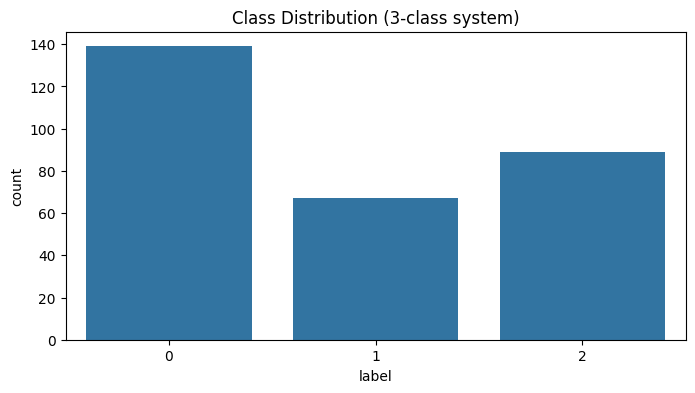

In [ ]:
# Verify labels

# Map to 3-class system (modify based on your original_label meanings)
class_mapping = {
    'ideation': 0,
    'behavior': 1,
    'supportive': 2,
    'severe': 2,    # Map severe to supportive
    'critical': 0   # Map critical to ideation
}
df['label'] = df['original_label'].map(class_mapping)

# Verify
print("Label distribution after mapping:")
print(df['label'].value_counts())
print("\nSample mapping:")
print(df[['original_label', 'label']].drop_duplicates())

# Clean data
df = df.dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)

# Visualize
plt.figure(figsize=(8,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution (3-class system)")
plt.show()

In [ ]:
# Cell 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']  # Maintain class balance
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=42,
    stratify=y_test
)

print(f"Train: {len(X_train)} samples")
print(f"Val: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

Train: 236 samples
Val: 29 samples
Test: 30 samples


In [ ]:
#Create PyTorch Dataset class
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Calculate class weights for imbalance
        class_counts = pd.Series(labels).value_counts().sort_index()
        self.class_weights = 1. / class_counts
        self.class_weights = self.class_weights / self.class_weights.sum()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx] if isinstance(self.texts, pd.Series) else self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels.iloc[idx] if isinstance(self.labels, pd.Series) else self.labels[idx], dtype=torch.long),
            'weight': torch.tensor(self.class_weights[self.labels.iloc[idx]] if isinstance(self.labels, pd.Series) else self.class_weights[self.labels[idx]], dtype=torch.float)
        }

In [ ]:
#Initialize tokenizer - USING STANDARD ROBERTA-BASE
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Verify tokenization
sample_text = X_train.iloc[0] if isinstance(X_train, pd.Series) else X_train[0]
print("Sample tokenization:")
print(f"Text: {sample_text[:100]}...")
print(f"Tokenized: {tokenizer.tokenize(sample_text)[:20]}...")

# Create datasets
train_dataset = MentalHealthDataset(X_train, y_train, tokenizer)
val_dataset = MentalHealthDataset(X_val, y_val, tokenizer)
test_dataset = MentalHealthDataset(X_test, y_test, tokenizer)

# Create DataLoaders with smaller batch size
batch_size = 4  # Reduced for GPU memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("\nDataLoaders created!")
print(f"Batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Sample tokenization:
Text: i agree, the suicide hotline fucking sucks. im sorry for your experience, that was all tired unneces...
Tokenized: ['i', 'Ġagree', ',', 'Ġthe', 'Ġsuicide', 'Ġhotline', 'Ġfucking', 'Ġsucks', '.', 'Ġim', 'Ġsorry', 'Ġfor', 'Ġyour', 'Ġexperience', ',', 'Ġthat', 'Ġwas', 'Ġall', 'Ġtired', 'Ġunnecessary']...

DataLoaders created!
Batch size: 4
Train batches: 59
Val batches: 8


In [ ]:
# Cell 8: Training function
def train_model(train_loader, val_loader, epochs=3, learning_rate=2e-5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🚀 Training on: {device}")

    # Model for 5 classes
    model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base',
        num_labels=5,
        problem_type="single_label_classification"
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_idx, batch in enumerate(train_loader):
            try:
                optimizer.zero_grad()

                inputs = {
                    'input_ids': batch['input_ids'].to(device),
                    'attention_mask': batch['attention_mask'].to(device),
                    'labels': batch['label'].to(device)
                }

                outputs = model(**inputs)
                loss = outputs.loss
                # Apply class weights
                loss = (loss * batch['weight'].to(device)).mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

                total_loss += loss.item()

                if batch_idx % 10 == 0:
                    print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

            except Exception as e:
                print(f"Error in batch {batch_idx}: {str(e)}")
                continue

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in val_loader:
                inputs = {
                    'input_ids': batch['input_ids'].to(device),
                    'attention_mask': batch['attention_mask'].to(device),
                    'labels': batch['label'].to(device)
                }
                outputs = model(**inputs)
                val_loss += outputs.loss.item()

                _, preds = torch.max(outputs.logits, 1)
                correct += (preds == inputs['labels']).sum().item()
                total += inputs['labels'].size(0)

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"Train Loss: {total_loss/len(train_loader):.4f}")
        print(f"Val Loss: {val_loss/len(val_loader):.4f}")
        print(f"Val Accuracy: {100*correct/total:.2f}%")
        print("-"*50)

    return model

In [ ]:
#Start training
# Clear GPU memory
torch.cuda.empty_cache()

# Start training
model = train_model(train_loader, val_loader, epochs=5)

🚀 Training on: cuda


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1 | Batch 0/59 | Loss: 0.3307
Epoch 1 | Batch 10/59 | Loss: 0.4628
Epoch 1 | Batch 20/59 | Loss: 0.8680
Epoch 1 | Batch 30/59 | Loss: 0.5192
Epoch 1 | Batch 40/59 | Loss: 0.2324
Epoch 1 | Batch 50/59 | Loss: 0.2057

Epoch 1 Summary:
Train Loss: 0.3700
Val Loss: 0.9646
Val Accuracy: 51.72%
--------------------------------------------------
Epoch 2 | Batch 0/59 | Loss: 0.1913
Epoch 2 | Batch 10/59 | Loss: 0.1695
Epoch 2 | Batch 20/59 | Loss: 0.2421
Epoch 2 | Batch 30/59 | Loss: 0.5544
Epoch 2 | Batch 40/59 | Loss: 0.1996
Epoch 2 | Batch 50/59 | Loss: 0.2905

Epoch 2 Summary:
Train Loss: 0.2575
Val Loss: 1.0365
Val Accuracy: 41.38%
--------------------------------------------------
Epoch 3 | Batch 0/59 | Loss: 0.2189
Epoch 3 | Batch 10/59 | Loss: 0.1497
Epoch 3 | Batch 20/59 | Loss: 0.4009
Epoch 3 | Batch 30/59 | Loss: 0.5376
Epoch 3 | Batch 40/59 | Loss: 0.3709
Epoch 3 | Batch 50/59 | Loss: 0.0865

Epoch 3 Summary:
Train Loss: 0.2507
Val Loss: 1.7527
Val Accuracy: 41.38%
----------

In [ ]:
#  Evaluation function
def evaluate(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            outputs = model(**inputs)
            _, preds = torch.max(outputs.logits, 1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch['label'].cpu().numpy())

    # Classification report
    print("📊 Classification Report:")
    print(classification_report(
        true_labels,
        predictions,
        target_names=['ideation', 'behavior', 'supportive'],
        digits=4
    ))

    # Confusion matrix
    plt.figure(figsize=(8,6))
    cm = confusion_matrix(true_labels, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['ideation', 'behavior', 'supportive'],
                yticklabels=['ideation', 'behavior', 'supportive'])
    plt.title('Confusion Matrix (3-class)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

🧪 Evaluating on test set...
📊 Classification Report:
              precision    recall  f1-score   support

    ideation     0.5385    1.0000    0.7000        14
    behavior     0.0000    0.0000    0.0000         7
  supportive     1.0000    0.4444    0.6154         9

    accuracy                         0.6000        30
   macro avg     0.5128    0.4815    0.4385        30
weighted avg     0.5513    0.6000    0.5113        30



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


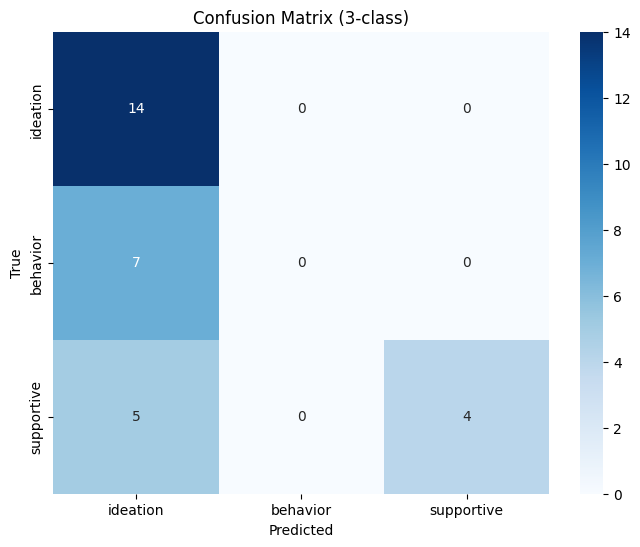

In [ ]:
# Run evaluation
print("🧪 Evaluating on test set...")
evaluate(model, test_loader)

In [ ]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 14.3 MB/s eta 0:00:00


In [ ]:
class MentalHealthDataset1(torch.utils.data.Dataset):
    def __init__(self, texts, labels, gender, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.gender = gender  # Include gender as an attribute
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        label = self.labels[index]
        gender = self.gender[index]  # Extract the gender for the current index

        # Tokenize the text
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long),
            'gender': gender  # Ensure gender is part of the returned batch
        }


# Step 4: Create Dataset Instances for Train and Test
train_dataset = MentalHealthDataset1(
    texts=X_train.tolist(), labels=y_train.tolist(), gender=gender_train.tolist(),
    tokenizer=tokenizer
)

test_dataset = MentalHealthDataset1(
    texts=X_test.tolist(), labels=y_test.tolist(), gender=gender_test.tolist(),
    tokenizer=tokenizer
)

# Step 5: Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Verify DataLoader by printing a sample batch
for batch in train_loader:
    print(batch)
    break  # Print just the first batch to verify


NameError: name 'gender_train' is not defined

In [ ]:
from fairlearn.metrics import MetricFrame
from fairlearn.reductions import EqualizedOdds, DemographicParity, GridSearch
from sklearn.metrics import accuracy_score
import torch

def fairness_analysis(model, test_loader, sensitive_attribute="gender"):
    # Initialize the sensitive attribute and its possible values
    sensitive_values = ['Male', 'Female', 'Unknown']  # Adjust based on your actual sensitive attribute values

    # Create a dictionary to map the sensitive values to numeric labels
    sensitive_map = {value.lower(): idx for idx, value in enumerate(sensitive_values)}  # Make all keys lowercase

    predictions = []
    true_labels = []
    sensitive_values_data = []

    # Make predictions on the test set
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
            }
            outputs = model(**inputs)
            _, preds = torch.max(outputs.logits, 1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch['label'].cpu().numpy())

            # Get sensitive values from the batch and map them to integers
            sensitive_values_batch = batch[sensitive_attribute]

            # Normalize and map string labels to numeric labels using the mapping
            sensitive_values_numeric = []
            for value in sensitive_values_batch:
                value_normalized = str(value).strip().lower()  # Normalize the value (lowercase and strip spaces)
                if value_normalized in sensitive_map:
                    sensitive_values_numeric.append(sensitive_map[value_normalized])
                else:
                    # If an unexpected value is found, append a default value or handle the error
                    sensitive_values_numeric.append(-1)  # -1 or another flag value for missing data or unknown values

            # Extend the sensitive values list with numeric values
            sensitive_values_data.extend(sensitive_values_numeric)

    # Convert to pandas DataFrame for ease of use
    df_results = pd.DataFrame({
        'predictions': predictions,
        'true_labels': true_labels,
        'sensitive_attribute': sensitive_values_data
    })

    # Fairness Evaluation: Demographic Parity
    metric_frame = MetricFrame(
        metrics={"accuracy": accuracy_score},
        y_true=df_results['true_labels'],
        y_pred=df_results['predictions'],
        sensitive_features=df_results['sensitive_attribute']
    )

    print("\nFairness Metrics using Demographic Parity:")
    print(metric_frame.by_group)

    # Fairness Evaluation: Equalized Odds (Equal Opportunity)
    print("\nFairness Metrics using Equalized Odds (Equal Opportunity):")

    # We need to perform equalized odds analysis using the proper function
    # EqualizedOdds requires the use of GridSearch to optimize the fairness reduction
    equalized_odds = EqualizedOdds()

    # GridSearch: Find the best model using the fairness reduction technique
    grid_search = GridSearch(estimator=model, constraints=equalized_odds)

    # Train the model using GridSearch (we'll use this method for fairness evaluation)
    grid_search.fit(df_results['true_labels'], df_results['predictions'], sensitive_features=df_results['sensitive_attribute'])

    # Evaluate fairness metrics after applying Equalized Odds
    print("Equalized Odds Fairness Evaluation Results:")
    print(grid_search.best_estimator_)

    # Fairness Evaluation: Disparate Impact
    group_sizes = df_results['sensitive_attribute'].value_counts()
    positive_rates = df_results.groupby('sensitive_attribute')['predictions'].mean()
    disparate_impact = positive_rates.min() / positive_rates.max()
    print("\nDisparate Impact Fairness Evaluation:")
    print(f"Disparate Impact Ratio: {disparate_impact:.4f}")


In [ ]:
# Assuming you have the model and test_loader prepared
fairness_analysis(model, test_loader, sensitive_attribute="gender")


KeyError: 'gender'

Fairness Analysis


In [ ]:
# Fairness Analysis Additions

### Cell 1: Add Fairness Libraries
!pip install fairlearn aif360 --quiet
from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    MetricFrame
)
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.algorithms.preprocessing import Reweighing
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 14.9 MB/s eta 0:00:00


pip install 'aif360[inFairness]'


In [ ]:
# Assuming your dataframe has 'gender' and 'age_group' columns
protected_features = df[['gender', 'age_group']].copy()

# Convert to binary protected attributes (example)
protected_features['gender_binary'] = protected_features['gender'].apply(
    lambda x: 1 if x.lower() in ['male', 'm'] else 0
)

# Age groups to binary (example)
protected_features['age_binary'] = protected_features['age_group'].apply(
    lambda x: 1 if x in ['18-24', '25-34'] else 0  # Young vs others
)

# Add to test dataset
X_test_df = pd.DataFrame({'text': X_test, 'label': y_test})
X_test_df = pd.concat([X_test_df, protected_features.loc[X_test_df.index]], axis=1)

In [ ]:
def evaluate_fairness(model, test_loader, protected_df):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            outputs = model(**inputs)
            _, preds = torch.max(outputs.logits, 1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch['label'].cpu().numpy())

    y_true = np.array(true_labels)
    y_pred = np.array(predictions)

    # 1. Per-class fairness analysis
    print("⚖️ Per-Class Fairness Metrics:")
    class_names = ['ideation', 'behavior', 'supportive']

    for class_idx, class_name in enumerate(class_names):
        print(f"\nClass: {class_name} (Label {class_idx})")

        # Binarize for this class
        y_true_bin = (y_true == class_idx).astype(int)
        y_pred_bin = (y_pred == class_idx).astype(int)

        # Calculate metrics
        dpd_gender = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['gender_binary']
        )

        dpd_age = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['age_binary']
        )

        eod_gender = equalized_odds_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['gender_binary']
        )

        eod_age = equalized_odds_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['age_binary']
        )

        print(f"Demographic Parity Difference (Gender): {dpd_gender:.4f}")
        print(f"Demographic Parity Difference (Age): {dpd_age:.4f}")
        print(f"Equalized Odds Difference (Gender): {eod_gender:.4f}")
        print(f"Equalized Odds Difference (Age): {eod_age:.4f}")

    # 2. Group-wise performance metrics
    print("\n📊 Performance by Protected Groups:")
    metrics = {
        'accuracy': lambda y_true, y_pred: (y_true == y_pred).mean(),
        'macro_f1': lambda y_true, y_pred: classification_report(
            y_true, y_pred, output_dict=True)['macro avg']['f1-score']
    }

    for feature in ['gender_binary', 'age_binary']:
        print(f"\nProtected Feature: {feature}")
        mf = MetricFrame(
            metrics=metrics,
            y_true=y_true,
            y_pred=y_pred,
            sensitive_features=protected_df[feature]
        )
        print(mf.by_group)

    # 3. Visualizations
    plt.figure(figsize=(15, 5))

    # Confusion Matrix
    plt.subplot(1, 2, 1)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')

    # Fairness Metrics Comparison
    plt.subplot(1, 2, 2)
    metrics_data = []
    for class_idx, class_name in enumerate(class_names):
        y_true_bin = (y_true == class_idx).astype(int)
        y_pred_bin = (y_pred == class_idx).astype(int)

        dpd_gender = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['gender_binary']
        )

        metrics_data.append({
            'Class': class_name,
            'Metric': 'DPD Gender',
            'Value': dpd_gender
        })

        dpd_age = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['age_binary']
        )

        metrics_data.append({
            'Class': class_name,
            'Metric': 'DPD Age',
            'Value': dpd_age
        })

    metrics_df = pd.DataFrame(metrics_data)
    sns.barplot(data=metrics_df, x='Class', y='Value', hue='Metric')
    plt.title('Fairness Metrics by Class')
    plt.axhline(0.1, color='red', linestyle='--', label='Acceptable Threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()

🧪 Running Fairness Evaluation...
⚖️ Per-Class Fairness Metrics:

Class: ideation (Label 0)
Demographic Parity Difference (Gender): 0.0000
Demographic Parity Difference (Age): 0.2201
Equalized Odds Difference (Gender): 0.0000
Equalized Odds Difference (Age): 0.3175

Class: behavior (Label 1)
Demographic Parity Difference (Gender): 0.0000
Demographic Parity Difference (Age): 0.0000
Equalized Odds Difference (Gender): 0.0000
Equalized Odds Difference (Age): 0.0000

Class: supportive (Label 2)
Demographic Parity Difference (Gender): 0.0000
Demographic Parity Difference (Age): 0.2201
Equalized Odds Difference (Gender): 0.1000
Equalized Odds Difference (Age): 0.3500

📊 Performance by Protected Groups:

Protected Feature: gender_binary
               accuracy  macro_f1
gender_binary                    
0                   0.6  0.423810
1                   0.6  0.455556

Protected Feature: age_binary


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

            accuracy  macro_f1
age_binary                    
0           0.578947  0.371429
1           0.636364  0.472222


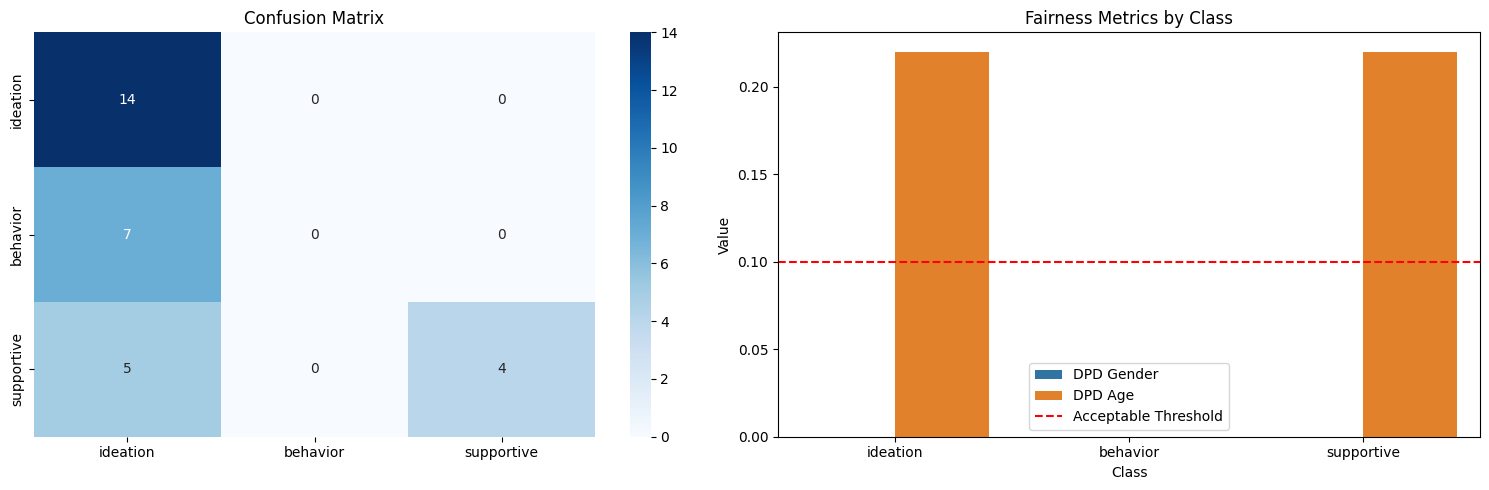

In [ ]:
# Get protected attributes for test set
test_indices = X_test.index if hasattr(X_test, 'index') else range(len(X_test))
protected_test = protected_features.loc[test_indices]

# Run evaluation
print("🧪 Running Fairness Evaluation...")
evaluate_fairness(model, test_loader, protected_test)